In [ ]:
!pip install transformers torch -q

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
#Configuration
import pandas as pd
import numpy as np
import os
import re
import unicodedata
import matplotlib.pyplot as plt
import json

# Seed for reproducibility
SEED = 42
np.random.seed(SEED)

# Paths
BASE_PATH = "/content/drive/MyDrive/Newslens.lk/phase_2"
RESULTS_DIR = f"{BASE_PATH}/results/e5"
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Results dir: {RESULTS_DIR}")



Results dir: /content/drive/MyDrive/Newslens.lk/phase_2/results/e5


In [ ]:
df = pd.read_csv(f"{BASE_PATH}/phase2_cleaned.csv")

with open(f"{BASE_PATH}/label_mapping.json", "r") as f:
    label_map = json.load(f)

id_to_label = {v: k for k, v in label_map.items()}
df["label_id"] = df["bias_label"].map(label_map)

print(f"Samples: {len(df)}")
print(f"\nLabel mapping: {label_map}")
print(f"\nClass distribution:")
print(df["bias_label"].value_counts())
print(f"\nNull check: {df[['body_text', 'label_id']].isnull().sum().to_dict()}")


Samples: 1655

Label mapping: {'Far Left': 0, 'Left': 1, 'Center': 2, 'Right': 3, 'Far Right': 4}

Class distribution:
bias_label
Center       740
Left         370
Right        339
Far Left     123
Far Right     83
Name: count, dtype: int64

Null check: {'body_text': 0, 'label_id': 0}


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel

device = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "intfloat/multilingual-e5-large"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)
model.eval()

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

...

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.24GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel(
  (embeddings): XLMRobertaEmbeddings(
    (word_embeddings): Embedding(250002, 1024, padding_idx=1)
    (token_type_embeddings): Embedding(1, 1024)
    (LayerNorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (position_embeddings): Embedding(514, 1024, padding_idx=1)
  )
  (encoder): XLMRobertaEncoder(
    (layer): ModuleList(
      (0-23): 24 x XLMRobertaLayer(
        (attention): XLMRobertaAttention(
          (self): XLMRobertaSelfAttention(
            (query): Linear(in_features=1024, out_features=1024, bias=True)
            (key): Linear(in_features=1024, out_features=1024, bias=True)
            (value): Linear(in_features=1024, out_features=1024, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): XLMRobertaSelfOutput(
            (dense): Linear(in_features=1024, out_features=1024, bias=True)
            (LayerNorm): LayerNorm((1024,), eps=1e-05, elementwi

In [ ]:
def build_passage_text(body):
    body = str(body).strip() if body else ""
    return "passage: " + body  # e5 requires this prefix

In [ ]:
df["passage_text"] = df.apply(
    lambda row: build_passage_text(row["text"]), axis=1
)

In [ ]:
def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts


def max_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).bool()
    # set padding tokens to a large negative value so they never win the max
    hidden = last_hidden_state.masked_fill(~mask, -1e9)
    return torch.max(hidden, dim=1).values

In [ ]:
POOLING_FNS = {
    "mean": mean_pooling,
    "max": max_pooling,
}

@torch.no_grad()
def embed_passages(texts, pooling="mean", batch_size=16, max_length=512):
    pool_fn = POOLING_FNS[pooling]
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        ).to(device)

        output = model(**encoded)
        pooled = pool_fn(output.last_hidden_state, encoded["attention_mask"])
        pooled = torch.nn.functional.normalize(pooled, p=2, dim=1)
        all_embeddings.append(pooled.cpu())

    return torch.cat(all_embeddings, dim=0).numpy()

mean: mean=0.7868 std=0.0282 min=0.6814 max=0.8867
max: mean=0.8739 std=0.0248 min=0.7641 max=0.9361


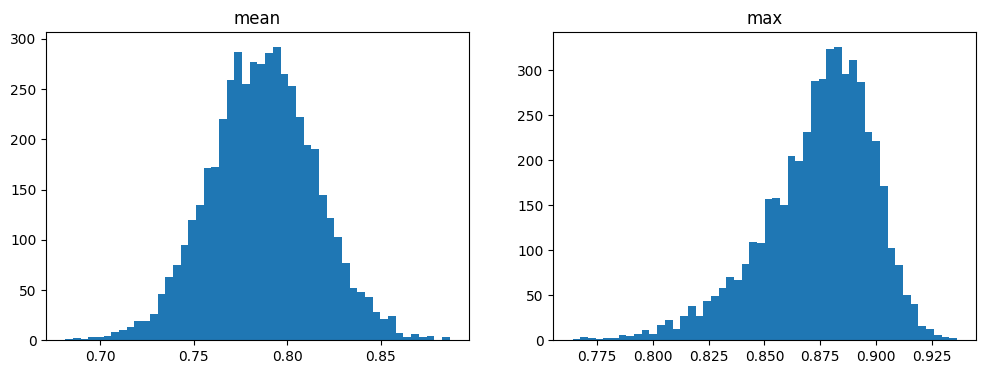

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

sample = df.sample(100, random_state=42)
sample_texts = sample["passage_text"].tolist()

results = {}
for strategy in ["mean", "max"]:
    emb = embed_passages(sample_texts, pooling=strategy, batch_size=16)
    sims = cosine_similarity(emb)
    pairwise = sims[np.triu_indices_from(sims, k=1)]
    results[strategy] = pairwise
    print(f"{strategy}: mean={pairwise.mean():.4f} std={pairwise.std():.4f} min={pairwise.min():.4f} max={pairwise.max():.4f}")

fig, axes = plt.subplots(1, len(results), figsize=(12, 4))
for ax, (strategy, pairwise) in zip(axes, results.items()):
    ax.hist(pairwise, bins=50)
    ax.set_title(strategy)
plt.show()

In [ ]:
best_strategy = "mean"  # set based on step 7's results

embeddings = embed_passages(df["passage_text"].tolist(), pooling=best_strategy, batch_size=16)
df["embedding"] = list(embeddings)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    np.stack(df["embedding"].values),
    df["label_id"].values,
    test_size=0.2,
    random_state=42,
    stratify=df["label_id"].values
)


In [ ]:
import xgboost as xgb

clf = xgb.XGBClassifier(n_estimators=200, max_depth=6, objective='multi:softmax', num_class=5)
clf.fit(X_train, y_train)
preds = clf.predict(X_test)

Accuracy: 0.5710
Macro F1: 0.3626

Classification Report:
              precision    recall  f1-score   support

    Far Left       0.43      0.12      0.19        25
        Left       0.41      0.41      0.41        74
      Center       0.69      0.84      0.76       148
       Right       0.47      0.46      0.46        68
   Far Right       0.00      0.00      0.00        16

    accuracy                           0.57       331
   macro avg       0.40      0.37      0.36       331
weighted avg       0.53      0.57      0.54       331



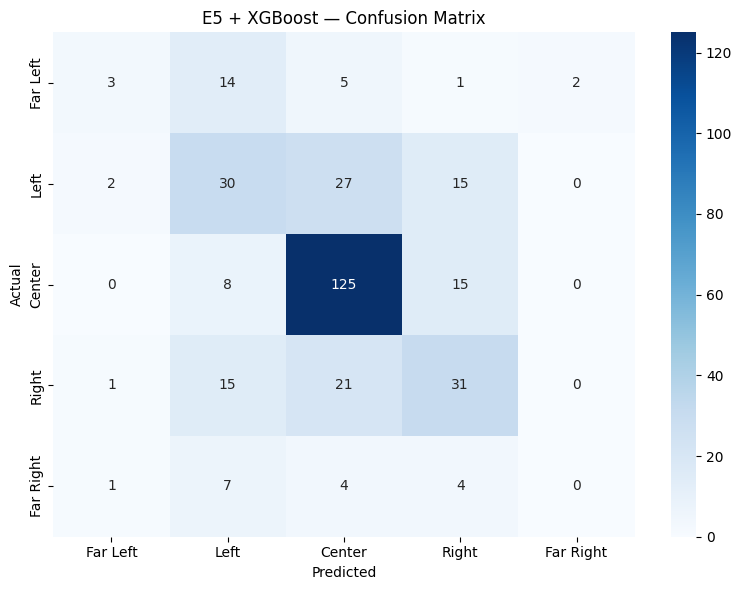

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# Metrics
label_names = ["Far Left", "Left", "Center", "Right", "Far Right"]

print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")
print(f"Macro F1: {f1_score(y_test, preds, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, preds, target_names=label_names))

# Confusion Matrix
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("E5 + XGBoost — Confusion Matrix")
plt.tight_layout()
plt.show()



In [ ]:
!pip install hdbscan -q

In [ ]:
import numpy as np

# df_valid from before — only rows with a real embedding
X = np.vstack(df["embedding"].values)
print(X.shape)  # (num_articles, 1024)

(1655, 1024)


In [ ]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=2,      # smallest group of articles to count as an "event" — 2 is permissive, tune this
    min_samples=1,           # lower = less conservative about noise
    metric="euclidean",      # valid since vectors are L2-normalized
    cluster_selection_method="eom",  # "excess of mass" — usually better than "leaf" for uneven cluster sizes
)

df["cluster_id"] = clusterer.fit_predict(X)

In [ ]:
print(df["cluster_id"].value_counts().head(20))
print("Noise (unclustered) articles:", (df["cluster_id"] == -1).sum())
print("Number of clusters found:", df["cluster_id"].nunique() - (1 if -1 in df["cluster_id"].values else 0))

cluster_id
-1      727
 322     10
 269      8
 7        8
 206      7
 238      6
 216      6
 71       6
 18       6
 343      6
 297      5
 183      5
 246      5
 277      5
 318      5
 240      5
 224      5
 128      5
 242      5
 191      5
Name: count, dtype: int64
Noise (unclustered) articles: 727
Number of clusters found: 347


In [ ]:
for cid, group in list(df[df["cluster_id"] != -1].groupby("cluster_id"))[20:40]:
    print(f"=== Cluster {cid} ({len(group)} articles) ===")
    for title in group["title"]:
        print(f"- {title}")
    print()


=== Cluster 20 (2 articles) ===
- බංග්ලාදේශයේ හමුදා ගුවන් යානයක් පාසලකට කඩා වැටෙයි
- මැලේසියාවේ හමුදා හෙලිකොප්ටර් දෙකක් ගුවනේදී ගැටෙයි

=== Cluster 21 (3 articles) ===
- Fox Hill අනතුර: සාමාන්‍ය මාර්ග නීති මෝටර් රථ ධාවන තරගයකටත් අදාළ කර ගත හැකි ද?
- Fox Hill ධාවන ශූරයෙක් වූ බුද්ධික ගැන සංවේදී කතාවක්
- දියතලාව බිහිසුණු ඛේදවාචකයේ නොදත් කතාව

=== Cluster 22 (2 articles) ===
- ශ්‍රී ලංකා රේගුව 2025 වසරේ ආදායම් ඉලක්ක පසු කරයි
- සංචාරක පැමිණීම ලක්ෂ 5 ඉක්මවයි

=== Cluster 23 (2 articles) ===
- කන්කසන්තුරේ සිට නැවෙන් ඉන්දියාවට යන්න අවශ්‍ය දෑ මොනවා ද?
- ඉන්දු - ශ්‍රී ලංකා මගී යාත්‍රා සේවය සිකුරාදා සිට

=== Cluster 24 (2 articles) ===
- ජනපති ට්‍රම්ප්ගේ සටන් විරාමය රැවටීමක්ද?
- ඊශ්‍රායල් නායකයා තවත් ඉලක්කයක් පෙන්වයි

=== Cluster 25 (2 articles) ===
- රාජ්‍ය අමාත්‍ය සනත් නිශාන්ත රිය අනතුරකින් ජීවිතක්ෂයට
- රාජ්‍ය අමාත්‍ය සනත් නිශාන්ත කියන්නේ කවුද ?

=== Cluster 26 (2 articles) ===
- පැනගිය හසීනාගෙන් අමෙරිකාවට චෝදනාවක්
- හෝටලයක සිටි 24 දෙනෙක් පණපිටින් පිළිස්සෙයි

=== Cluster 27 (2 articles) ===
- ආ